### Implement Boston housing price prediction problem by Linear regression using Deep Neural network. Use Boston House price prediction dataset.

In [ ]:
#1. libraries
import matplotlib.pyplot as plt #library, create graph, charts, etc
import tensorflow as tf #library, build and train neural networks
import numpy as np #library, numerical operations, handle array
import pandas as pd #library, handle data frame i.e tables
print("all libraries installed and imported")

all libraries installed and imported


In [ ]:
#2. load df
df=pd.read_csv('Boston-house-price-data.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
#3. preprocess
from sklearn.preprocessing import StandardScaler
#library for classification, regression, clustering, etc

X=df.drop('MEDV', axis=1)
Y=df['MEDV']

scaler=StandardScaler() #Creates a StandardScaler object used for scaling data.
X=scaler.fit_transform(X)
#fit() → calculates mean and standard deviation of data
#transform() → scales the data using formula
#now data has mean=0, std=1 so data standardized i.e
# Large and small values in similar scale (10,20,30 becomes -1.2,0,1.2)

print(X[:5]) #print first 5 rows

#0 → value is exactly average
#Positive value → above average
#Negative value → below average

[[-0.41978194  0.28482986 -1.2879095  -0.27259857 -0.14421743  0.41367189
  -0.12001342  0.1402136  -0.98284286 -0.66660821 -1.45900038  0.44105193
  -1.0755623 ]
 [-0.41733926 -0.48772236 -0.59338101 -0.27259857 -0.74026221  0.19427445
   0.36716642  0.55715988 -0.8678825  -0.98732948 -0.30309415  0.44105193
  -0.49243937]
 [-0.41734159 -0.48772236 -0.59338101 -0.27259857 -0.74026221  1.28271368
  -0.26581176  0.55715988 -0.8678825  -0.98732948 -0.30309415  0.39642699
  -1.2087274 ]
 [-0.41675042 -0.48772236 -1.30687771 -0.27259857 -0.83528384  1.01630251
  -0.80988851  1.07773662 -0.75292215 -1.10611514  0.1130321   0.41616284
  -1.36151682]
 [-0.41248185 -0.48772236 -1.30687771 -0.27259857 -0.83528384  1.22857665
  -0.51117971  1.07773662 -0.75292215 -1.10611514  0.1130321   0.44105193
  -1.02650148]]


In [ ]:
#4. split dataset
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X,Y,test_size=0.3, random_state=42)
#random-state means everytime code runs, split is done randomly
# without it, we get same split each time

#Training data: x_train (354 rows, 13 cols) y_train(354 rows,)
# only 1 column in Y so empty for columns in Y

Training data: (354, 13) (354,)
Testing data: (152, 13) (152,)


In [ ]:
#5. define model
from tensorflow.keras.models import Sequential
#sequential model has layers one after the other in sequence

from tensorflow.keras.layers import Dense, Dropout
#dense layer is fully connected layer like input,hidden,output layer
#dropout layer randomly disables neurons to prevent overfitting or
#over-relying of model on specific neurons

from tensorflow.keras.callbacks import EarlyStopping
#stop training of model when it stops improving to save time,avoid overfittting

model=Sequential() #model name is 'model'
model.add(Dense(64, input_dim=13, activation='relu')) #input layer, 64 neurons
#input_dim means input dimensions/columns given i.e 13
#ReLU is Rectified Linear Unit. keeps positive values as is but
#changes negative values to 0
#relu used here because prices cannot be negative and
#to introduce non-linearity or complex relationships

model.add(Dropout(0.2)) #20% of neurons are randomly turned off during training
model.add(Dense(32, activation='relu')) #hidden layer of 32 neurons
model.add(Dense(1)) #output layer of 1 neuron
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#6. compile model
model.compile(
    loss='mean_squared_error',
    #measures how far the predicted values are from actual values.

    optimizer='adam', #reduces error, backpropagation
    #Wrong prediction,calculate error,Adam updates weights,prediction improves

    metrics=['mean_absolute_error']
    #measures the average difference between actual and predicted values.

    #loss is what the model uses to learn and improve
    #MSE squares errors, so values can become large and harder to interpret

    #metrics are just used to show performance to humans
    #MAE gives simple average error in normal units

    #MSE → good for model learning, hence used for training
    #MAE → good for human understanding, hence used  t9 show performance
)


In [ ]:
#7.train model
early_stopping = EarlyStopping(monitor='val_loss', patience=5)
#Watch the validation loss (val_loss).
#If it does not improve for 5 epochs continuously, stop training automatically
#validation loss calculated automatically when validation data given

historyvariable=model.fit(
    #here model.fit trains model and returns training info, which is
    #stored in variable history
    x_train, y_train,

    validation_split=0.2,
    #20% of training data is used for validation i.e
    #Used during training to check model performance and tune training.

    epochs=100,
    #Model will train maximum 100 times on the full dataset.
    #1 epoch = one complete pass through training data.(iteration, loop)
    # model doesnt learn completely in just 1 epoch
    #in epoch 1, weights improve a little
    #In epoch 2, predictions become better
    #In epoch 3, error reduces more and so on.
    #So multiple epochs help model learn patterns better from same data slowly.


    batch_size=32,
    #whole training dataset is divided into batches of size of 32 samples
    #samples means rows
    #using whole dataset at once is very slow and memory-consuming
    #so data is processed in batches of 32 samples
    #this is faster and memory efficient
    #here 324 rows are made into batches of 32 samples each so 324/32=11 batches

    #So in 1 epoch:
    #first 32 samples trained, then next 32, until all 354 samples are used
    #Then next epoch starts again from the beginning.


    callbacks=[early_stopping]
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 636.2006 - mean_absolute_error: 23.3155 - val_loss: 580.8291 - val_mean_absolute_error: 22.6029
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 610.2023 - mean_absolute_error: 22.7197 - val_loss: 557.3644 - val_mean_absolute_error: 22.0534
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 586.0549 - mean_absolute_error: 22.0980 - val_loss: 533.8739 - val_mean_absolute_error: 21.4854
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 559.3246 - mean_absolute_error: 21.4448 - val_loss: 508.8301 - val_mean_absolute_error: 20.8664
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 534.8246 - mean_absolute_error: 20.7968 - val_loss: 480.2188 - val_mean_absolute_error: 20.1435
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 502.6627 - mean_absolute_error: 19.9661 - val_loss: 446.8414 - val_mean_absolute_error: 19.2819
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 464.8164 - mean_ab

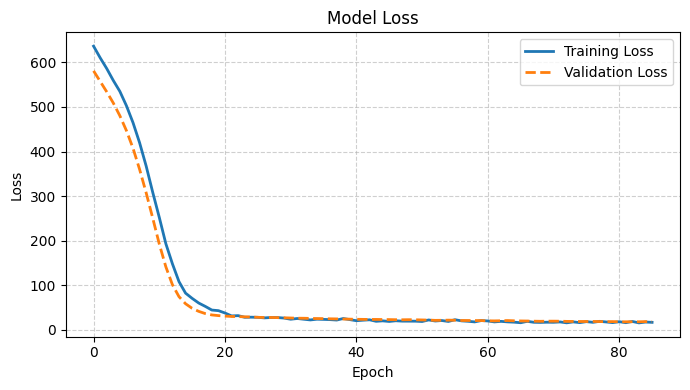

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(
    historyvariable.history['loss'], #library.model['column name']
    #model name is 'model'
    #model.fit trains model and gives training info which is
    #stored in historyvariable
    #historyvariable has attribute history in it which stores loss values
    #loss values were given earlier as mse

    linestyle='-', linewidth=2, label='Training Loss'
         )

plt.plot(
    historyvariable.history['val_loss'],
    linestyle='--', linewidth=2, label="Validation Loss"
)

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(frameon=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#graph to check how the model is learning over epochs
#if loss going down, model learning properly
#training line plotted to check if training happening properly
#validation line plotted to check if model overfitted or not

In [ ]:
#8. evaluate model
loss,mae=model.evaluate(x_test,y_test)
print("mae:", mae)
#loss mse=13.65
#mae=2.44 (predicted house prices off by 2.44 units from actual prices on avg)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13.6569 - mean_absolute_error: 2.4430
mae: 2.443002700805664
